In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Spotify dataset
df = pd.read_csv("spotify_tracks_with_metadata_10000.csv")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset shape: (10000, 10)

First few rows:
        track_name      artist      genre playlist_category  danceability  \
0         Love Sky  Artist_464  Classical             Chill         0.375   
1       Fire Dream  Artist_221  Bollywood          Romantic         0.951   
2      Light Night  Artist_357       Jazz             Sleep         0.732   
3  Love Wave Night  Artist_389        Pop           Workout         0.599   
4       Fire Light  Artist_451        EDM           Workout         0.156   

   energy  valence   tempo  duration_ms  popularity  
0   0.374    0.730  149.34       329908          89  
1   0.333    0.185  124.30       339603          91  
2   0.176    0.347  195.03       130658          87  
3   0.607    0.663   90.66        90342          71  
4   0.477    0.482  142.30       233893          48  

Column names:
['track_name', 'artist', 'genre', 'playlist_category', 'danceability', 'energy', 'valence', 'tempo', 'duration_ms', 'popularity']

Data types:
track_name 

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select relevant features for clustering
features = ['popularity', 'energy', 'danceability', 'valence']

# Handle missing values
X = df[features].dropna().copy()

print(f"Data shape after removing NaN: {X.shape}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Get centroids in original scale
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Add cluster labels to dataframe
df_clustered = df[features].dropna().copy()
df_clustered['cluster'] = labels

# Define cluster names based on characteristics
cluster_names = {}
for i, c in enumerate(centroids_original):
    popularity, energy, danceability, valence = c
    
    if energy > 0.6 and danceability > 0.6:
        cluster_names[i] = "High Energy Dance"
    elif energy > 0.5 and valence > 0.5:
        cluster_names[i] = "Upbeat Positive"
    elif energy < 0.4 and valence < 0.4:
        cluster_names[i] = "Low Energy Calm"
    else:
        cluster_names[i] = "Balanced Mix"

df_clustered['cluster_name'] = df_clustered['cluster'].map(cluster_names)

print("\nFirst few clustered rows:")
print(df_clustered.head(10))
print("\nCluster distribution:")
print(df_clustered['cluster'].value_counts().sort_index())
print("\nCluster characteristics:")
print(cluster_names)

Data shape after removing NaN: (10000, 4)

First few clustered rows:
   popularity  energy  danceability  valence  cluster  cluster_name
0          89   0.374         0.375    0.730        1  Balanced Mix
1          91   0.333         0.951    0.185        2  Balanced Mix
2          87   0.176         0.732    0.347        2  Balanced Mix
3          71   0.607         0.599    0.663        1  Balanced Mix
4          48   0.477         0.156    0.482        0  Balanced Mix
5          10   0.866         0.156    0.739        0  Balanced Mix
6          89   0.032         0.058    0.961        1  Balanced Mix
7          54   0.644         0.866    0.117        2  Balanced Mix
8          35   0.763         0.601    0.710        3  Balanced Mix
9          24   0.759         0.708    0.230        3  Balanced Mix

Cluster distribution:
cluster
0    2554
1    2468
2    2501
3    2477
Name: count, dtype: int64

Cluster characteristics:
{0: 'Balanced Mix', 1: 'Balanced Mix', 2: 'Balanced Mix', 3:

WCSS values: [40000.00000000006, 32460.054774562675, 27862.65770523853, 24210.10498660802, 21437.90962418959, 19461.038663252246, 17529.207002104067, 15664.077887994788, 14735.148491273103, 13837.507054691941]


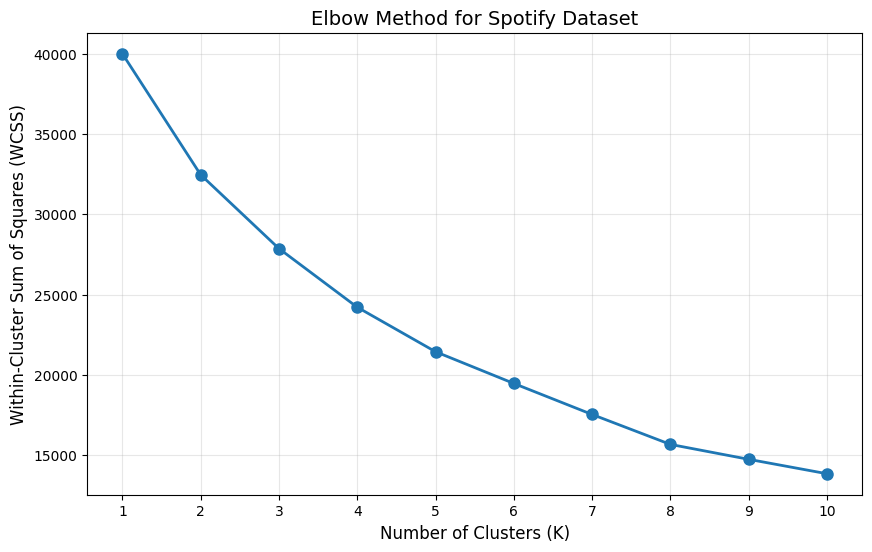


Elbow curve plotted successfully!


In [3]:
import matplotlib.pyplot as plt

# Elbow method to find optimal number of clusters
wcss = []

for k in range(1, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

print("WCSS values:", wcss)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)
plt.title("Elbow Method for Spotify Dataset", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

print("\nElbow curve plotted successfully!")

In [4]:
# Predict cluster for a new track
new_track = [[75, 0.8, 0.7, 0.6]]  # [popularity, energy, danceability, valence]

new_track_scaled = scaler.transform(new_track)
predicted_cluster = kmeans.predict(new_track_scaled)

print(f"New track features: {new_track[0]}")
print(f"Predicted cluster: {predicted_cluster[0]}")
print(f"Cluster name: {cluster_names[predicted_cluster[0]]}")

# Summary statistics per cluster
print("\nCluster Summary Statistics:")
for cluster_id in sorted(df_clustered['cluster'].unique()):
    cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
    print(f"\n{cluster_names[cluster_id]} (Cluster {cluster_id}):")
    print(f"  Count: {len(cluster_data)}")
    print(f"  Avg Popularity: {cluster_data['popularity'].mean():.2f}")
    print(f"  Avg Energy: {cluster_data['energy'].mean():.2f}")
    print(f"  Avg Danceability: {cluster_data['danceability'].mean():.2f}")
    print(f"  Avg Valence: {cluster_data['valence'].mean():.2f}")

New track features: [75, 0.8, 0.7, 0.6]
Predicted cluster: 1
Cluster name: Balanced Mix

Cluster Summary Statistics:

Balanced Mix (Cluster 0):
  Count: 2554
  Avg Popularity: 26.27
  Avg Energy: 0.50
  Avg Danceability: 0.23
  Avg Valence: 0.46

Balanced Mix (Cluster 1):
  Count: 2468
  Avg Popularity: 74.68
  Avg Energy: 0.48
  Avg Danceability: 0.44
  Avg Valence: 0.77

Balanced Mix (Cluster 2):
  Count: 2501
  Avg Popularity: 72.65
  Avg Energy: 0.55
  Avg Danceability: 0.53
  Avg Valence: 0.23

Balanced Mix (Cluster 3):
  Count: 2477
  Avg Popularity: 27.95
  Avg Energy: 0.48
  Avg Danceability: 0.77
  Avg Valence: 0.55


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
